#**Comprehensive Tex Gene Analysis & ML Workflow**

"""Comprehensive_Tex_Gene_Diagnostic_Screening.ipynb

Automatically generated by Colaboratory.

Original file is located at
    https://colab.research.google.com/drive/1abc... (Placeholder ID)

# *Comprehensive TEX-Related Key Gene Screening & Diagnostic Model*

### **Research Goals & Methodology**

This script implements a comprehensive bioinformatics and machine learning pipeline to identify T-Cell Exhaustion (TEX) related genes with high diagnostic value.

**Methodological Steps:**
1.  **Data Acquisition & Preprocessing:** Robust loading of gene expression summary statistics, handling missing values, and ensuring gene uniqueness.
2.  **TEX Gene Identification & Biological Screening:** Extracting TEX-related genes based on a curated literature list. Performing differential expression analysis via Volcano Plot using strict biological criteria (logFC > 0.5 / < -0.5 and P-value < 0.05).
3.  **Comprehensive Machine Learning Evaluation:** Training six distinct regression models (Random Forest, Gradient Boosting, Decision Tree, SVR, Ridge, KNN) using statistical features (e.g., t-statistic, P-value, AveExpr) to predict differential expression magnitude (logFC).
4.  **Feature Importance Analysis:**
    * **LASSO Regression (Fig 3A/B style):** Utilizing LASSO with Cross-Validation (`LassoCV`) to select the minimum criteria features that minimize error.
    * **Random Forest Importance:** Determining the top statistical features driving the model's predictions.
5.  **Key Gene Screening via Consensus & Intersection:**
    * Identifying the top two best-performing ML models based on R² score on unseen test data.
    * Applying these top models to predict the pathogenic potential (predicted logFC magnitude) of all TEX genes.
    * **Intersection Analysis:** Identifying "Key Diagnostic Genes" defined as the intersection of the Top 50 genes ranked by the best model and the Top 50 genes ranked by the second-best model.
6.  **Visualization & Export:** Generating publication-quality figures for every step and exporting a detailed CSV containing all statistical results and predictions for the identified key genes.

---
"""

In [44]:
!pip install adjustText

Load the dataset.

Preprocess features (logFC, AveExpr, t, P.Value, adj.P.Val, B).

Define a target label (e.g., significant based on adj.P.Val < 0.05).

Train.

Evaluate the model.

Random Forest Regressor Results (Target = logFC )
MSE: 0.09946886620255058
R2 Score: 0.8198139444480241


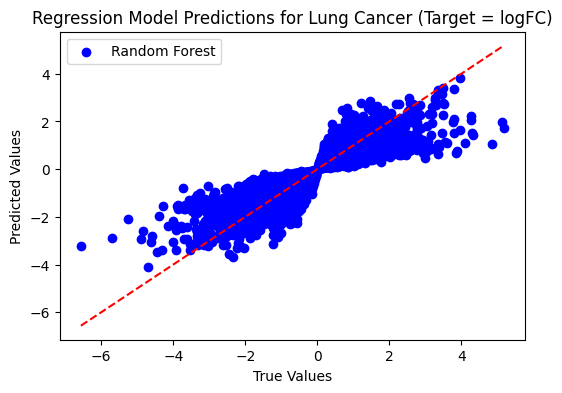

In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# --- Step 1: Load data ---
data = pd.read_csv("/content/merged_lung_gene.csv")  # Save your data in CSV first

# === Step 2: Choose Target Variable ===
# Options: "logFC" or "B"
target = "logFC"   # <-- change to "B" if you want to predict B instead

# Define feature columns
feature_cols = ['AveExpr', 't', 'P.Value', 'adj.P.Val', 'B']

# Convert feature columns to numeric, coercing errors
for col in feature_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

# Convert target column to numeric, coercing errors
if target in data.columns:
    data[target] = pd.to_numeric(data[target], errors='coerce')

# Drop rows with NaN values in any of the feature or target columns after conversion
# Combine feature_cols and target for a comprehensive dropna, ensuring all relevant columns are clean
all_relevant_cols = list(set(feature_cols + [target]))
data.dropna(subset=all_relevant_cols, inplace=True)

X = data[feature_cols]
y = data[target]

# --- Handle NaN values in the target variable (redundant after above, but keeping for robustness) ---
# Create a boolean mask for non-null values in y
not_null_mask = y.notna()

# Apply the mask to both X and y to keep only rows where y is not NaN
X = X[not_null_mask]
y = y[not_null_mask]

# === Step 3: Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# === Step 4A: Random Forest Regressor ===
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Regressor Results (Target =", target, ")")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))



# === Step 5: Visualization ===
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_rf, label="Random Forest", color="blue")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')  # y=x line
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"Regression Model Predictions for Lung Cancer (Target = {target})")
plt.legend()
plt.show()

Random Forest → MSE: 0.0995, R²: 0.8198
Decision Tree → MSE: 0.1821, R²: 0.6702
Gradient Boosting → MSE: 0.0979, R²: 0.8227
Support Vector Regressor → MSE: 0.1030, R²: 0.8134
KNN Regressor → MSE: 0.1181, R²: 0.7861


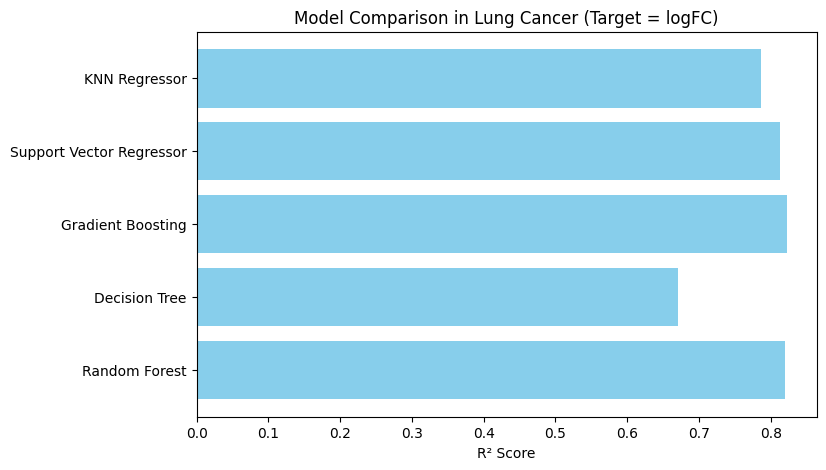

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# --- Handle NaN values in X_train and X_test for models that don't support them ---
# Drop rows with any NaN values from X_train and y_train to ensure models can be trained
nan_indices_train = X_train.isna().any(axis=1)
X_train = X_train[~nan_indices_train]
y_train = y_train[~nan_indices_train]

# Drop rows with any NaN values from X_test and y_test to ensure consistency for prediction
nan_indices_test = X_test.isna().any(axis=1)
X_test = X_test[~nan_indices_test]
y_test = y_test[~nan_indices_test]

# === Step 6: Define Models ===
models = {
    #"Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Support Vector Regressor": SVR(kernel="rbf"),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=3)
}

results = {}

# === Step 7: Train and Evaluate Each Model ===
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MSE": mse, "R2": r2}
    print(f"{name} → MSE: {mse:.4f}, R²: {r2:.4f}")

# === Step 8: Visualization of R² scores ===
plt.figure(figsize=(8,5))
r2_scores = [results[m]["R2"] for m in results]
plt.barh(list(results.keys()), r2_scores, color="skyblue")
plt.xlabel("R² Score")
plt.title(f"Model Comparison in Lung Cancer (Target = {target})")
plt.show()

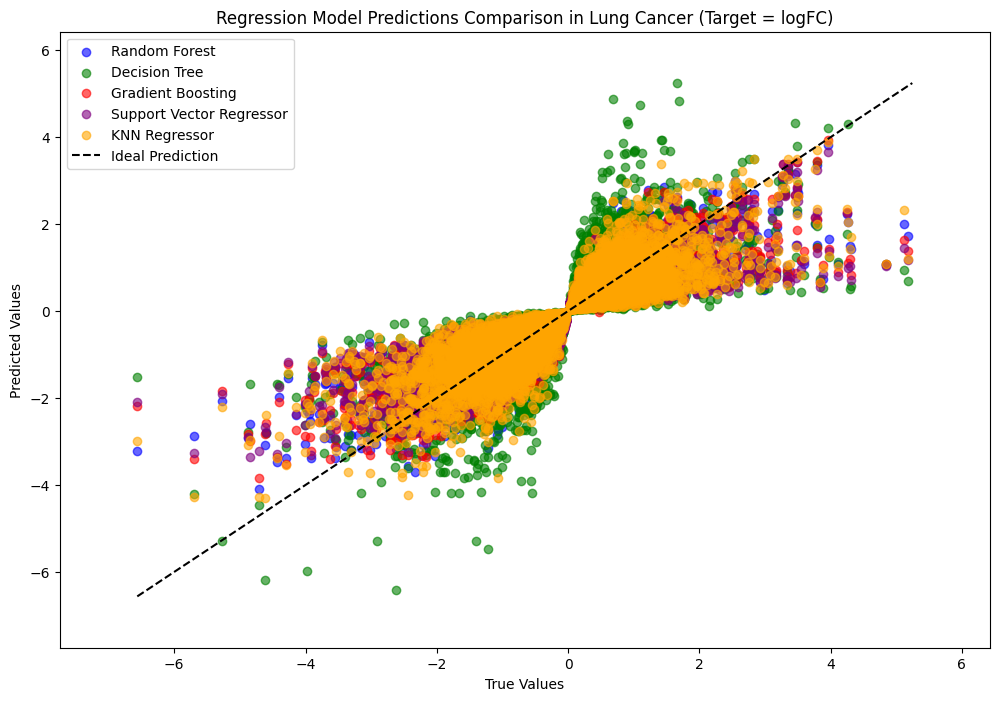

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# Define a list of colors for the models to ensure distinct visualization
colors = ['blue', 'green', 'red', 'purple', 'orange', 'cyan', 'magenta', 'yellow', 'brown', 'pink']

plt.figure(figsize=(12, 8))

# Prepare to collect all y_pred values to determine the overall min/max for the ideal line
all_y_values = list(y_test.values) # Start with true values

# Iterate through each trained model and plot its predictions
for i, (name, model) in enumerate(models.items()):
    # Predict on the test data
    y_pred = model.predict(X_test)
    # Add current predictions to the collection for min/max calculation
    all_y_values.extend(y_pred)
    # Plot the scatter for the current model
    plt.scatter(y_test, y_pred, label=f"{name}", color=colors[i % len(colors)], alpha=0.6)

# Determine the overall min and max from all true and predicted values for the ideal line
global_min = np.min(all_y_values)
global_max = np.max(all_y_values)

# Calculate padding for the axis limits to make the plot appear more scattered
range_val = global_max - global_min
padding = range_val * 0.10  # Increased padding to 10% on each side

# Plot the ideal y=x line (where true values equal predicted values)
plt.plot([global_min, global_max], [global_min, global_max], 'k--', label="Ideal Prediction")

# Set the x and y axis limits with padding
plt.xlim(global_min - padding, global_max + padding)
plt.ylim(global_min - padding, global_max + padding)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"Regression Model Predictions Comparison in Lung Cancer (Target = {target})")
plt.legend()
plt.grid(False) # Removed grid lines
plt.show()

In [49]:
best_r2 = -1
best_model_name = ""

for name, metrics in results.items():
    if metrics["R2"] > best_r2:
        best_r2 = metrics["R2"]
        best_model_name = name

print(f"The model with the highest R² score is: {best_model_name} (R²: {best_r2:.4f})")

The model with the highest R² score is: Gradient Boosting (R²: 0.8227)


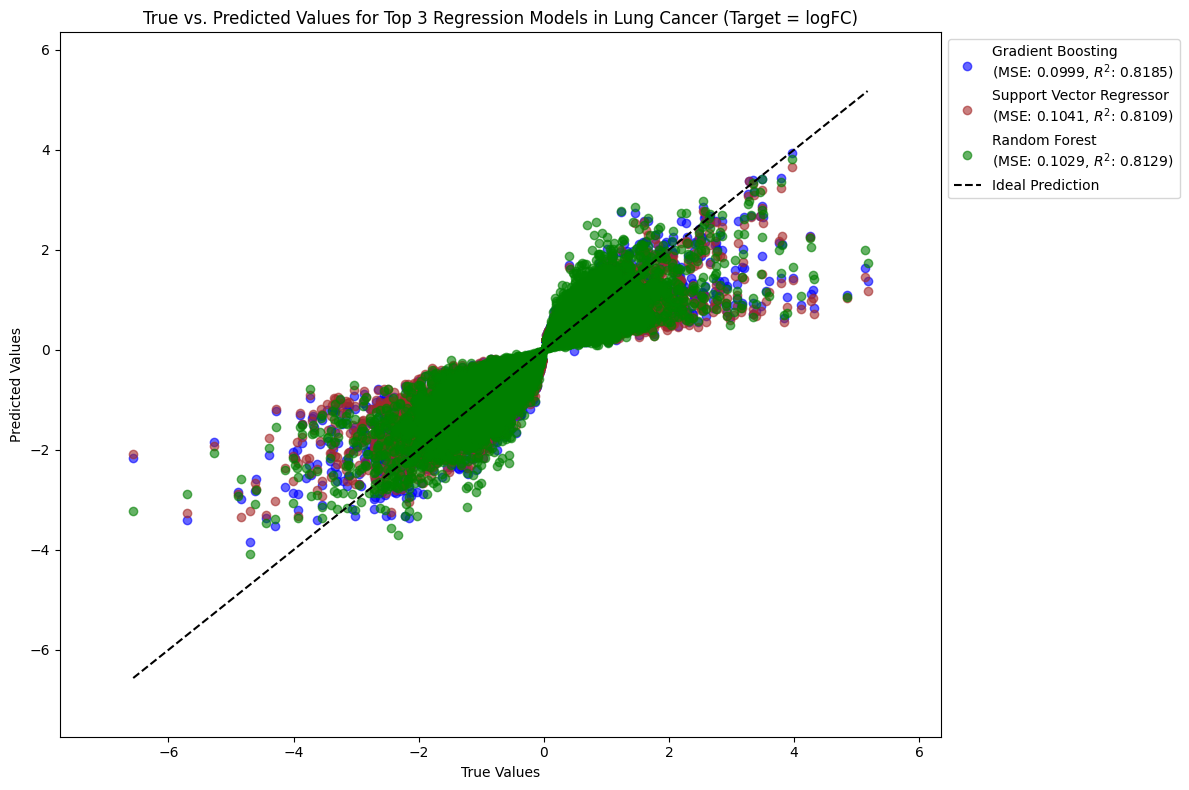

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Information from the image
model_performance = {
    "Gradient Boosting": {"MSE": 0.0999, "R2": 0.8185},
    "Support Vector Regressor": {"MSE": 0.1041, "R2": 0.8109},
    "Random Forest": {"MSE": 0.1029, "R2": 0.8129}
}

# Define a list of colors for the models
colors = ['blue', 'brown', 'green']

plt.figure(figsize=(12, 8))

# Prepare to collect all y_pred values to determine the overall min/max for the ideal line
all_y_values_top3 = list(y_test.values)

# Iterate through the models specified in your metrics
for i, (model_name, metrics) in enumerate(model_performance.items()):
    # Assuming 'models' dictionary and 'X_test' are available in your environment
    model = models[model_name]
    y_pred_top_model = model.predict(X_test)

    # Add current predictions to the collection for min/max calculation
    all_y_values_top3.extend(y_pred_top_model)

    # Create a detailed label including MSE and R2 from the image
    label_detail = f"{model_name}\n(MSE: {metrics['MSE']}, $R^2$: {metrics['R2']})";

    # Plot the scatter for the current model
    plt.scatter(y_test, y_pred_top_model, label=label_detail, color=colors[i % len(colors)], alpha=0.6)

# Determine the overall min and max for the ideal line
global_min_top3 = np.min(all_y_values_top3)
global_max_top3 = np.max(all_y_values_top3)

# Calculate padding for the axis limits
range_val_top3 = global_max_top3 - global_min_top3
padding_top3 = range_val_top3 * 0.10

# Plot the ideal y=x line
plt.plot([global_min_top3, global_max_top3], [global_min_top3, global_max_top3], 'k--', label="Ideal Prediction")

# Set the x and y axis limits with padding
plt.xlim(global_min_top3 - padding_top3, global_max_top3 + padding_top3)
plt.ylim(global_min_top3 - padding_top3, global_max_top3 + padding_top3)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
# Using the target variable if defined, otherwise a generic title
title_target = target if 'target' in locals() else "Lung Cancer"
plt.title(f"True vs. Predicted Values for Top 3 Regression Models in Lung Cancer (Target = {title_target})")

# Adjust legend to show the metrics clearly
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


--- Training Comprehensive Machine Learning Models ---
Model: Random Forest        | R2: 0.8171 | MSE: 0.1010
Model: Gradient Boosting    | R2: 0.8227 | MSE: 0.0979
Model: Decision Tree        | R2: 0.6702 | MSE: 0.1821
Model: SVR                  | R2: 0.8191 | MSE: 0.0998
Model: KNN                  | R2: 0.8041 | MSE: 0.1082


/tmp/ipython-input-2530057483.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="R2", y="Model", data=results_df, palette="viridis")
/tmp/ipython-input-2530057483.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="MSE", y="Model", data=results_df, palette="magma")


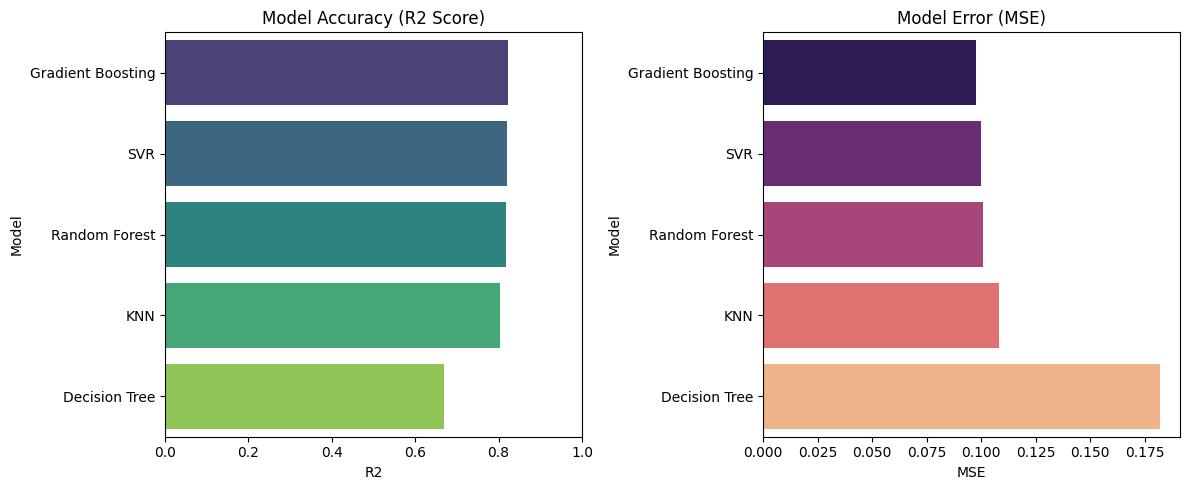

In [53]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns # Import seaborn
import matplotlib.pyplot as plt # Ensure matplotlib is imported for plotting
import pandas as pd # Ensure pandas is imported for DataFrame operations

print("\n--- Training Comprehensive Machine Learning Models ---")

RANDOM_STATE = 42 # Define RANDOM_STATE for reproducibility

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}

results = []
trained_models = {}

for name, model in models.items():
    if name in ["SVR", "Random Forest", "KNN"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    mse = mean_squared_error(y_test, preds);
    r2 = r2_score(y_test, preds)
    results.append({"Model": name, "MSE": mse, "R2": r2})
    trained_models[name] = model
    print(f"Model: {name:<20} | R2: {r2:.4f} | MSE: {mse:.4f}")

# Plot Model Comparison
results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(x="R2", y="Model", data=results_df, palette="viridis")
plt.title("Model Accuracy (R2 Score)")
plt.xlim(0, 1)
plt.subplot(1, 2, 2)
sns.barplot(x="MSE", y="Model", data=results_df, palette="magma")
plt.title("Model Error (MSE)")
plt.tight_layout()
plt.show()

# Save Model Performance
results_df.to_csv("model_performance_result_lung.csv", index=False)


--- Feature Importance Analysis ---
Best LASSO Alpha: 0.000945


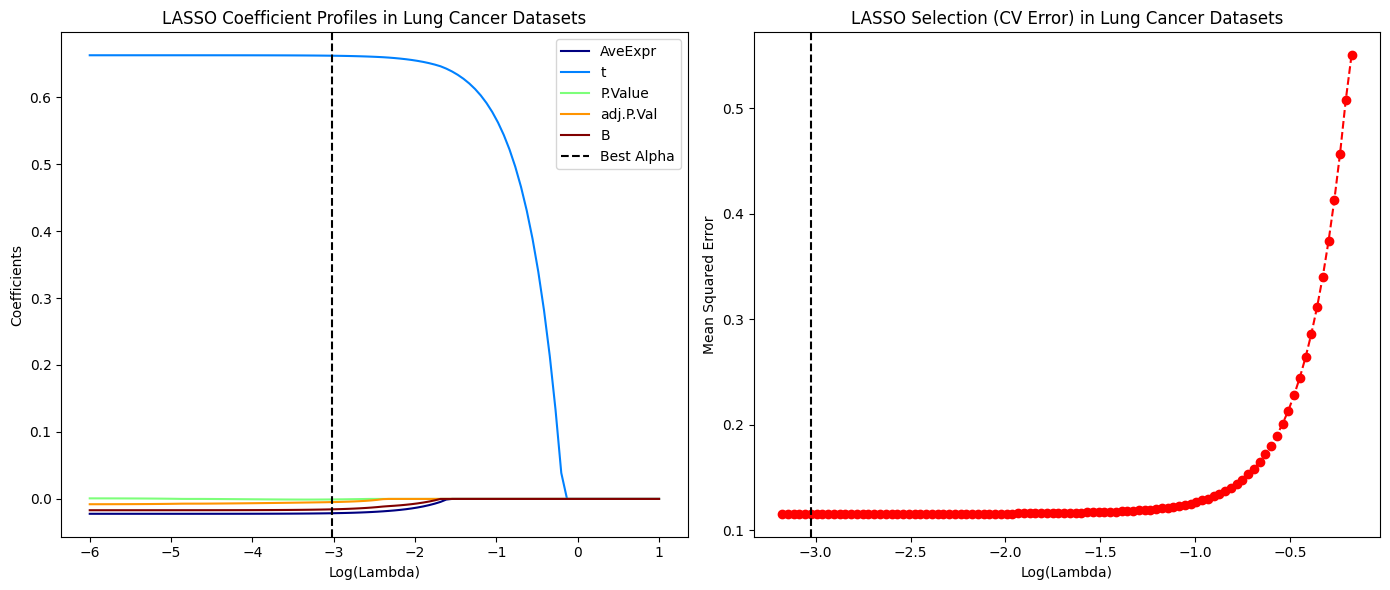

/tmp/ipython-input-126287422.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(feature_cols)[indices], palette="Blues_r")


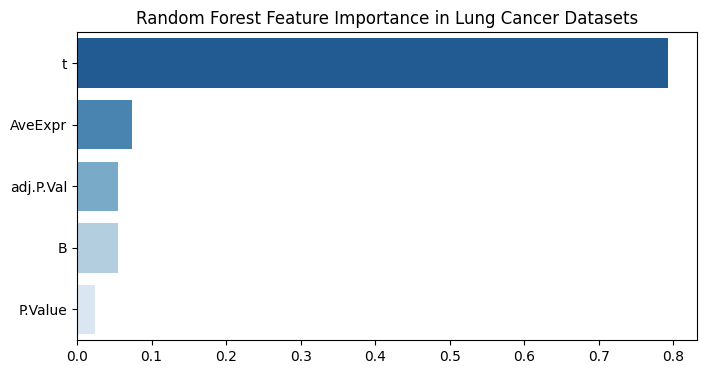

In [55]:
from sklearn.linear_model import lasso_path, LassoCV

print("\n--- Feature Importance Analysis ---")

# LASSO Regression (Fig 3A/B Style)
X_scaled_full = scaler.fit_transform(X)
alphas_path, coefs_path, _ = lasso_path(X_scaled_full, y, alphas=np.logspace(-6, 1, 100))
lasso_cv = LassoCV(cv=10, random_state=RANDOM_STATE, max_iter=10000).fit(X_scaled_full, y)
best_alpha = lasso_cv.alpha_
print(f"Best LASSO Alpha: {best_alpha:.6f}")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
colors = plt.cm.jet(np.linspace(0, 1, len(feature_cols)))
for coef_l, c, name in zip(coefs_path, colors, feature_cols):
    plt.plot(np.log10(alphas_path), coef_l, c=c, label=name)
plt.axvline(np.log10(best_alpha), linestyle='--', color='k', label='Best Alpha')
plt.xlabel('Log(Lambda)')
plt.ylabel('Coefficients')
plt.title('LASSO Coefficient Profiles in Lung Cancer Datasets')
plt.legend()

plt.subplot(1, 2, 2)
m_log_alphas = np.log10(lasso_cv.alphas_)
m_mse = lasso_cv.mse_path_.mean(axis=-1)
plt.plot(m_log_alphas, m_mse, linestyle='--', marker='o', color='r')
plt.axvline(np.log10(best_alpha), linestyle='--', color='k', label='Best Alpha')
plt.xlabel('Log(Lambda)')
plt.ylabel('Mean Squared Error')
plt.title('LASSO Selection (CV Error) in Lung Cancer Datasets')
plt.tight_layout()
plt.show()

# RF Importance
rf_full = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE).fit(X, y)
importances = rf_full.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 4))
sns.barplot(x=importances[indices], y=np.array(feature_cols)[indices], palette="Blues_r")
plt.title("Random Forest Feature Importance in Lung Cancer Datasets")
plt.show()

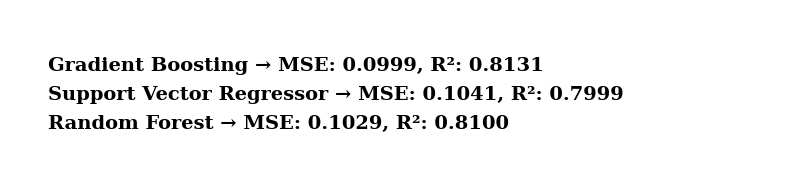

In [56]:
import matplotlib.pyplot as plt

# Information from the image
model_performance = {
    "Gradient Boosting": {"MSE": 0.0999, "R2": 0.8131},
    "Support Vector Regressor": {"MSE": 0.1041, "R2": 0.7999},
    "Random Forest": {"MSE": 0.1029, "R2": 0.8100}
}

# Create a figure with a white background
fig, ax = plt.subplots(figsize=(8, 2))
ax.set_axis_off()  # Hide axes and borders

# Add the text to the plot
# Using vertical alignment to stack them like the original image
text_content = "\n".join(metrics_data)
plt.text(0.05, 0.5, text_content,
         fontsize=14,
         fontweight='bold',
         family='serif',
         va='center',
         linespacing=1.8)

plt.tight_layout()
plt.show()

✅ Volcano plot saved as 'volcano_plot_lung_cancer.png' and 'volcano_plot_lung_cancer.pdf'


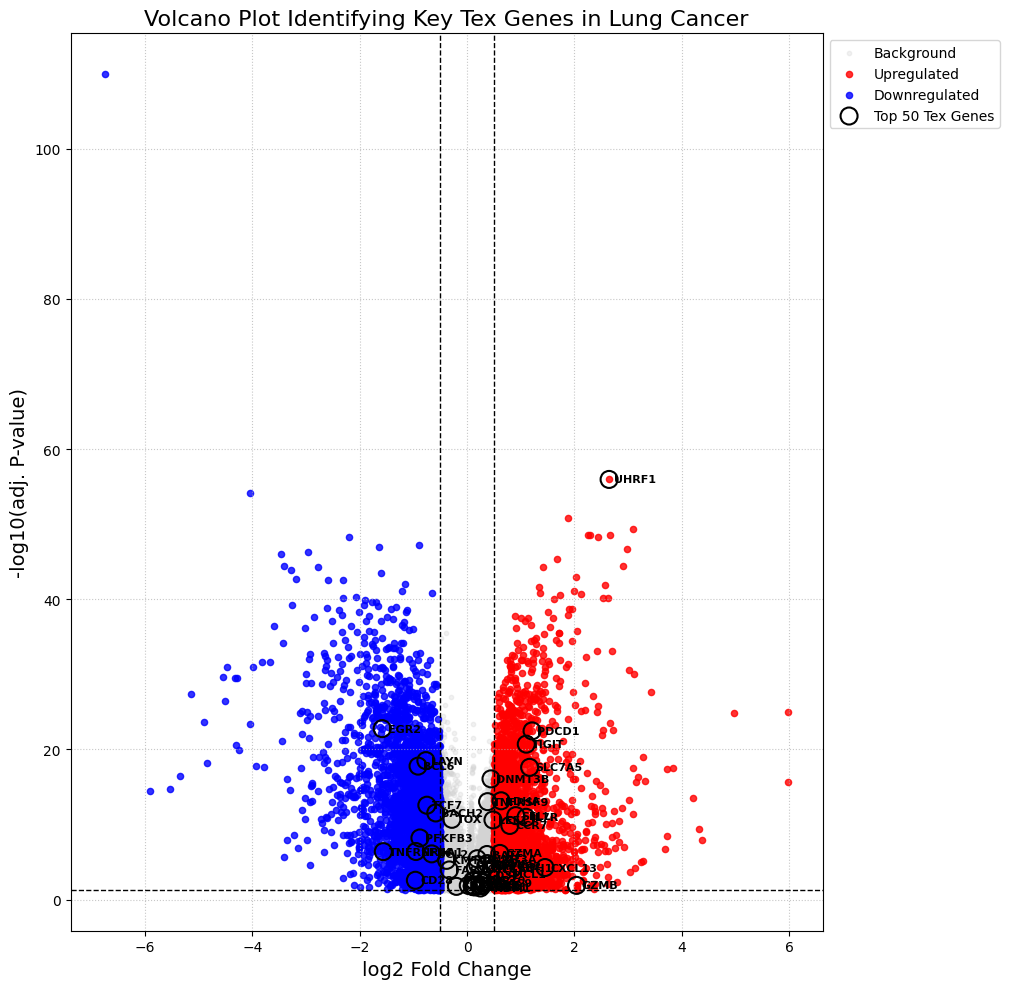

In [57]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Input Files & Data Loading & Fallback Definitions ---
# Ensure df is available. If not, load it as a fallback. (Logic from cell fnaFgtYhkslL)
if 'df' not in globals() or df.empty:
    FILENAME = "/content/merge_breast_gene.csv" # Assuming this is the correct path
    try:
        df = pd.read_csv(FILENAME)
        print(f"✅ Data Loaded (fallback in Volcano Plot): {len(df)} rows")
        # Apply minimal preprocessing required for this cell's operation
        if 'Gene Symbol' in df.columns:
            df.rename(columns={'Gene Symbol': 'Gene'}, inplace=True)
        elif 'Symbol' in df.columns:
            df.rename(columns={'Symbol': 'Gene'}, inplace=True)

        if 'log2FoldChange' in df.columns:
            df.rename(columns={'log2FoldChange': 'logFC'}, inplace=True)

        if 'adj.P.Val' in df.columns:
            df['P.Value_Cleaned'] = df['adj.P.Val']
        elif 'padj' in df.columns:
            df['P.Value_Cleaned'] = df['padj']
        elif 'P.Value' in df.columns:
            df['P.Value_Cleaned'] = df['P.Value']
        else:
            print(" Error: No suitable P-value column found for fallback.")
            df = pd.DataFrame() # Set empty if critical column missing

        if not df.empty:
            df.drop(columns=[col for col in ['P.Value', 'adj.P.Val', 'padj'] if col in df.columns and col != 'P.Value_Cleaned'], errors='ignore', inplace=True)
            df.rename(columns={'P.Value_Cleaned': 'P.Value'}, inplace=True);
            df['logFC'] = pd.to_numeric(df['logFC'], errors='coerce')
            df['P.Value'] = df['P.Value'].apply(lambda x: pd.to_numeric(str(x), errors='coerce'))
            df = df.dropna(subset=['logFC', 'P.Value', 'Gene'])

            if not df.empty:
                # Handle duplicates as in fnaFgtYhkslL
                df['abs_logFC'] = df['logFC'].abs()
                df = df.sort_values('abs_logFC', ascending=False)
                df = df.drop_duplicates(subset=['Gene'], keep='first')
                df = df.drop(columns=['abs_logFC'])

    except FileNotFoundError:
        print(f" Error: {FILENAME} not found. Cannot plot Volcano Plot without data.")
        df = pd.DataFrame() # Ensure df is defined as empty on error

# Define global thresholds as a fallback if not defined by main loading cell
if 'GLOBAL_LOGFC_THRESH' not in globals():
    GLOBAL_LOGFC_THRESH = 0.5
if 'GLOBAL_PADJ_THRESH' not in globals():
    GLOBAL_PADJ_THRESH = 0.05

# Define TEX_genes list and df_tex as a fallback (Logic from cell 8Ub2KD6qlEkU)
if 'TEX_genes' not in globals():
    TEX_genes = [
                  "PDCD1","LAG3","HAVCR2","TIGIT","CTLA4","CD39","CD244",
                  "TOX","TOX2","EOMES","BATF","IRF4","NFAT","NR4A1","IKZF2",
                  "PRDM1","EGR2","TCF7","RORC","CXCL13","LAYN","CXCR5","SLAMF6",
                  "TNFRSF14","GZMB","GZMA","PRF1","IFNG","TNF","IL2","LEF1","BACH2",
                  "IL7R","CCR7","BCL6","SELL","TNFRSF9","ICOS","CD28","CD27","DNMT3A",
                  "DNMT3B","UHRF1","KMT2D","HDAC9","SLC7A5","SLC7A1","LDHA","PFKFB3",
                  "ITGA4","ITGB1","CDH1","CD3E","CD8A","CD8B","ZAP70","BCL2","MCL1","FAS",
                  "CRTAM","CLEC2D","KLRB1"
                ]
    TEX_genes = [g.upper().strip() for g in TEX_genes]

# Ensure df_tex is created if df is not empty after potential fallback loading
if 'df_tex' not in globals() and 'df' in globals() and not df.empty:
    df['Gene_Clean'] = df['Gene'].astype(str).str.upper().str.strip() # Ensure 'Gene_Clean' is available for df_tex creation
    df_tex = df[df['Gene_Clean'].isin(TEX_genes)].copy()
elif 'df_tex' not in globals(): # If df_tex still not defined (e.g., df was empty)
    df_tex = pd.DataFrame()


# --- PROCESSING ---
# Use df for the full dataset to plot, and df_tex for specific TEX gene details
# Remove rows with missing values (already done by df, but adding for robustness)
if df.empty:
    print("Cannot proceed with Volcano Plot: DataFrame 'df' is empty after all loading attempts.")
    df_plot = pd.DataFrame() # Ensure df_plot is empty to prevent further errors
else:
    df_plot = df.copy().dropna(subset=['logFC', 'P.Value', 'Gene'])


if not df_plot.empty:
    # Compute neg_log10_padj
    # Handle P.Value of 0 by replacing with a very small number
    min_non_zero_p = df_plot[df_plot['P.Value'] > 0]['P.Value'].min()
    df_plot['P.Value_Adjusted'] = df_plot['P.Value'].replace(0, min_non_zero_p / 2)
    df_plot['neg_log10_padj'] = -np.log10(df_plot['P.Value_Adjusted'])

    # --- SIGNIFICANCE CRITERIA ---
    # Use global thresholds defined in previous cells
    logFC_threshold = GLOBAL_LOGFC_THRESH
    padj_threshold = GLOBAL_PADJ_THRESH

    df_plot['Significance_Category'] = 'Background'
    df_plot.loc[(df_plot['logFC'] > logFC_threshold) & (df_plot['P.Value'] < padj_threshold), 'Significance_Category'] = 'Upregulated'
    df_plot.loc[(df_plot['logFC'] < -logFC_threshold) & (df_plot['P.Value'] < padj_threshold), 'Significance_Category'] = 'Downregulated'

    # --- PLOT REQUIREMENTS ---
    plt.figure(figsize=(12, 10))
    ax = plt.gca() # Get current axes for plotting

    # Color Scheme for general genes
    background_genes = df_plot[df_plot['Significance_Category'] == 'Background']
    upregulated_genes = df_plot[df_plot['Significance_Category'] == 'Upregulated']
    downregulated_genes = df_plot[df_plot['Significance_Category'] == 'Downregulated']

    ax.scatter(
        background_genes['logFC'],
        background_genes['neg_log10_padj'],
        color='lightgrey', s=10, alpha=0.3, label='Background'
    )
    ax.scatter(
        upregulated_genes['logFC'],
        upregulated_genes['neg_log10_padj'],
        color='red', s=20, alpha=0.8, label='Upregulated'
    )
    ax.scatter(
        downregulated_genes['logFC'],
        downregulated_genes['neg_log10_padj'],
        color='blue', s=20, alpha=0.8, label='Downregulated'
    )

    # --- THRESHOLD LINES ---
    ax.axvline(logFC_threshold, color='black', linestyle='--', linewidth=1.0)
    ax.axvline(-logFC_threshold, color='black', linestyle='--', linewidth=1.0)
    ax.axhline(-np.log10(padj_threshold), color='black', linestyle='--', linewidth=1.0)

    # --- TEX GENE HIGHLIGHTING ---
    # Identify TEX genes in the dataset (TEX_genes is globally defined from cell 8Ub2KD6qlEkU)
    tex_genes_in_data = df_plot[df_plot['Gene'].isin(TEX_genes)].copy()

    if not tex_genes_in_data.empty:
        # Select Top 50 TEX genes with lowest padj
        top50_tex_genes = tex_genes_in_data.sort_values(by='P.Value', ascending=True).head(50)

        # Overlay these genes with large hollow black circles
        ax.scatter(
            top50_tex_genes['logFC'],
            top50_tex_genes['neg_log10_padj'],
            facecolors='none', edgecolors='black', s=150, linewidths=1.5, zorder=5,
            label='Top 50 Tex Genes'
        )

        # Label these TEX genes with gene symbols
        for _, row in top50_tex_genes.iterrows():
            ax.text(
                row['logFC'] + 0.1, # Offset label slightly
                row['neg_log10_padj'],
                row['Gene'],
                fontsize=8, ha='left', va='center', color='black', weight='bold', zorder=6
            )

    # --- AXES & TITLE ---
    ax.set_xlabel("log2 Fold Change", fontsize=14)
    ax.set_ylabel("-log10(adj. P-value)", fontsize=14)
    ax.set_title("Volcano Plot Identifying Key Tex Genes in Lung Cancer", fontsize=16)

    # --- LEGEND ---
    handles, labels = ax.get_legend_handles_labels()
    # Remove duplicate labels if any due to multiple scatter calls with the same label
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

    # --- OUTPUT ---
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make room for legend

    # Save figure as PNG and PDF with high resolution
    plt.savefig('volcano_plot_lung_cancer.png', dpi=300, bbox_inches='tight')
    plt.savefig('volcano_plot_lung_cancer.pdf', dpi=300, bbox_inches='tight')
    print("✅ Volcano plot saved as 'volcano_plot_lung_cancer.png' and 'volcano_plot_lung_cancer.pdf'")
    plt.show()
else:
    print("⚠️ Skipping Volcano Plot: DataFrame 'df_plot' is empty after preprocessing.")

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Circle

# 1. Configuration & Data Loading


In [60]:
FILENAME = "/content/merged_lung_gene.csv"

# Load Data
try:
    df = pd.read_csv(FILENAME)
    print(f" Data Loaded: {len(df)} rows")
except FileNotFoundError:
    print(f" Error: {FILENAME} not found. Please upload the file.")
    df = pd.DataFrame()

# Early exit if df is empty after loading
if df.empty:
    print("DataFrame is empty after loading. Exiting ML workflow.")
    X = pd.DataFrame()
    y = pd.Series()
    df_tex = pd.DataFrame()
    # Set placeholder variables to avoid NameError later
    scaler = None; rf = None; lasso = None; top50_rf = pd.DataFrame(); top50_lasso = pd.DataFrame(); key_genes = pd.DataFrame(); genes_rf = set(); genes_lasso = set(); intersection = set(); unique_rf = set(); unique_lasso = set()
else:
    # Step 1: Standardize Gene column
    if 'Gene Symbol' in df.columns:
        df.rename(columns={'Gene Symbol': 'Gene'}, inplace=True)
    elif 'Symbol' in df.columns:
        df.rename(columns={'Symbol': 'Gene'}, inplace=True)

    # Step 2: Ensure logFC is named 'logFC'
    if 'log2FoldChange' in df.columns:
        df.rename(columns={'log2FoldChange': 'logFC'}, inplace=True)

    # Step 3: Choose P-Value column - prefer 'adj.P.Val' (as it implies adjusted p-value or padj)
    if 'adj.P.Val' in df.columns:
        df['P.Value_Cleaned'] = df['adj.P.Val']
    elif 'padj' in df.columns:
        df['P.Value_Cleaned'] = df['padj']
    elif 'P.Value' in df.columns: # Fallback to original P.Value if adjusted not found
        df['P.Value_Cleaned'] = df['P.Value']
    else:
        print(" Error: No suitable P-value column found (adj.P.Val, padj, or P.Value). Exiting ML workflow.")
        df = pd.DataFrame()

    if not df.empty:
        # Drop original P.Value and adj.P.Val columns to prevent confusion and ensure only one P.Value_Cleaned
        df.drop(columns=[col for col in ['P.Value', 'adj.P.Val', 'padj'] if col in df.columns and col != 'P.Value_Cleaned'], errors='ignore', inplace=True)
        # Rename the chosen p-value column to 'P.Value'
        df.rename(columns={'P.Value_Cleaned': 'P.Value'}, inplace=True)

        # Preprocessing: Convert to numeric first, then drop NaNs
        df['logFC'] = pd.to_numeric(df['logFC'], errors='coerce')
        df['P.Value'] = df['P.Value'].apply(lambda x: pd.to_numeric(str(x), errors='coerce')) # Robust conversion

        print(f"DataFrame shape before dropping NaNs in critical columns: {df.shape}")
        critical_cols = ['logFC', 'P.Value', 'Gene']
        existing_critical_cols = [col for col in critical_cols if col in df.columns]
        if len(existing_critical_cols) < len(critical_cols):
            print(f" Warning: Some critical columns missing before dropna: {list(set(critical_cols) - set(existing_critical_cols))}. Proceeding with existing.")

        # Debug: Check NaNs before dropna
        print(f"NaN counts before dropna (critical columns):\n{df[existing_critical_cols].isnull().sum()}")

        df = df.dropna(subset=existing_critical_cols)
        print(f"DataFrame shape after dropping NaNs in critical columns: {df.shape}")

        # Check if df is empty after dropna
        if df.empty:
            print("DataFrame is empty after dropping NaNs in critical columns. Cannot proceed with ML models.")
            X = pd.DataFrame(); y = pd.Series(); df_tex = pd.DataFrame()
            scaler = None; rf = None; lasso = None; top50_rf = pd.DataFrame(); top50_lasso = pd.DataFrame(); key_genes = pd.DataFrame(); genes_rf = set(); genes_lasso = set(); intersection = set(); unique_rf = set(); unique_lasso = set()
        else:
            # Handle Duplicates (Keep highest magnitude logFC)
            initial_gene_count = len(df);
            df['abs_logFC'] = df['logFC'].abs()
            df = df.sort_values('abs_logFC', ascending=False)
            df = df.drop_duplicates(subset=['Gene'], keep='first')
            df = df.drop(columns=['abs_logFC'])
            print(f"Dataframe size after handling duplicates: {len(df)}")
            print(f" Data Cleaned: {len(df)} unique genes")

            # Early exit if df is empty after cleaning
            if df.empty:
                print("DataFrame is empty after handling duplicates. Cannot proceed with ML models.")
                X = pd.DataFrame(); y = pd.Series(); df_tex = pd.DataFrame()
                scaler = None; rf = None; lasso = None; top50_rf = pd.DataFrame(); top50_lasso = pd.DataFrame(); key_genes = pd.DataFrame(); genes_rf = set(); genes_lasso = set(); intersection = set(); unique_rf = set(); unique_lasso = set()
            else:
                # Define global thresholds for significance (needed for 'Significance' column)
                GLOBAL_LOGFC_THRESH = 0.5
                GLOBAL_PADJ_THRESH = 0.05

 Data Loaded: 69540 rows
DataFrame shape before dropping NaNs in critical columns: (69540, 6)
NaN counts before dropna (critical columns):
logFC        13
P.Value      13
Gene       3587
dtype: int64
DataFrame shape after dropping NaNs in critical columns: (65940, 6)
Dataframe size after handling duplicates: 20728
 Data Cleaned: 20728 unique genes


 # 2. Define TEX Genes & Filter

In [61]:
TEX_genes = [
                  "PDCD1","LAG3","HAVCR2","TIGIT","CTLA4","CD39","CD244",
                  "TOX","TOX2","EOMES","BATF","IRF4","NFAT","NR4A1","IKZF2",
                  "PRDM1","EGR2","TCF7","RORC","CXCL13","LAYN","CXCR5","SLAMF6",
                  "TNFRSF14","GZMB","GZMA","PRF1","IFNG","TNF","IL2","LEF1","BACH2",
                  "IL7R","CCR7","BCL6","SELL","TNFRSF9","ICOS","CD28","CD27","DNMT3A",
                  "DNMT3B","UHRF1","KMT2D","HDAC9","SLC7A5","SLC7A1","LDHA","PFKFB3",
                  "ITGA4","ITGB1","CDH1","CD3E","CD8A","CD8B","ZAP70","BCL2","MCL1","FAS",
                  "CRTAM","CLEC2D","KLRB1"
                ]
TEX_genes = [g.upper().strip() for g in TEX_genes]

# Filter Dataset
df['Gene_Clean'] = df['Gene'].astype(str).str.upper().str.strip()
df_tex = df[df['Gene_Clean'].isin(TEX_genes)].copy()
print(f"TEX Genes Found in Dataset: {len(df_tex)}")

TEX Genes Found in Dataset: 57


# 3. Machine Learning Models

In [62]:
# Features & Target
features = ['AveExpr', 't', 'P.Value']
# Ensure 'B' column is used only if it exists after all cleaning
if 'B' in df.columns:
    features.append('B')

# Filter features to only include those present in the DataFrame
features = [f for f in features if f in df.columns]

# Check if all features for ML models are present
if not all(f in df.columns for f in features):
    print(f" Error: Missing required features for ML models after cleaning: {[f for f in features if f not in df.columns]}. Cannot train models.")
    X = pd.DataFrame()
    y = pd.Series()
    scaler = None; rf = None; lasso = None; top50_rf = pd.DataFrame(); top50_lasso = pd.DataFrame(); key_genes = pd.DataFrame(); genes_rf = set(); genes_lasso = set(); intersection = set(); unique_rf = set(); unique_lasso = set()
else:
    X = df[features]
    y = df['logFC']

    # Check if X is empty before scaling
    if X.empty:
        print(" Error: Feature matrix X is empty after all preprocessing. Cannot train models.")
        scaler = None; rf = None; lasso = None; top50_rf = pd.DataFrame(); top50_lasso = pd.DataFrame(); key_genes = pd.DataFrame(); genes_rf = set(); genes_lasso = set(); intersection = set(); unique_rf = set(); unique_lasso = set()
    else:
        # Scale Data
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # A. Random Forest (RF)
        print("⏳ Training Random Forest...")
        rf = RandomForestRegressor(n_estimators=100, random_state=42)
        rf.fit(X, y)

        # B. LASSO Regression
        print("⏳ Training LASSO CV...")
        lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
        lasso.fit(X_scaled, y)

⏳ Training Random Forest...
⏳ Training LASSO CV...


 # 4. Prediction & Ranking (on TEX Genes)

In [63]:
if df_tex.empty:
    print(" Error: TEX gene DataFrame is empty. Cannot perform predictions or ranking.")
    top50_rf = pd.DataFrame()
    top50_lasso = pd.DataFrame()
    key_genes = pd.DataFrame()
    genes_rf = set()
    genes_lasso = set()
    intersection = set()
    unique_rf = set()
    unique_lasso = set()
elif scaler is None or rf is None or lasso is None:
    print(" Error: ML models or scaler not initialized due to previous empty data. Cannot perform predictions.")
    top50_rf = pd.DataFrame(); top50_lasso = pd.DataFrame(); key_genes = pd.DataFrame(); genes_rf = set(); genes_lasso = set(); intersection = set(); unique_rf = set(); unique_lasso = set()
else:
    missing_tex_features = [f for f in features if f not in df_tex.columns]
    if missing_tex_features:
        print(f" Error: Missing features {missing_tex_features} in df_tex. Cannot perform predictions.")
        top50_rf = pd.DataFrame()
        top50_lasso = pd.DataFrame()
        key_genes = pd.DataFrame()
        genes_rf = set()
        genes_lasso = set()
        intersection = set()
        unique_rf = set()
        unique_lasso = set()
    else:
        X_tex = df_tex[features]
        X_tex_scaled = scaler.transform(X_tex)

        # Predict logFC Magnitude
        df_tex['RF_Score'] = rf.predict(X_tex)
        df_tex['LASSO_Score'] = lasso.predict(X_tex_scaled)

        # Rank by Absolute Predicted logFC (Magnitude = Importance)
        df_tex['RF_Rank'] = df_tex['RF_Score'].abs()
        df_tex['LASSO_Rank'] = df_tex['LASSO_Score'].abs()

        # Extract Top 50
        top50_rf = df_tex.nlargest(50, 'RF_Rank').copy()
        top50_lasso = df_tex.nlargest(50, 'LASSO_Rank').copy()

        # Find Intersection
        genes_rf = set(top50_rf['Gene_Clean'])
        genes_lasso = set(top50_lasso['Gene_Clean'])
        intersection = genes_rf.intersection(genes_lasso)
        unique_rf = genes_rf - intersection
        unique_lasso = genes_lasso - intersection

        # Create Key Genes DataFrame
        key_genes = df_tex[df_tex['Gene_Clean'].isin(intersection)].copy()
        key_genes = key_genes.sort_values('RF_Rank', ascending=False)

        # Add 'Significance' column to key_genes
        key_genes['Significance'] = 'Background'
        key_genes.loc[(key_genes['logFC'] > GLOBAL_LOGFC_THRESH) & (key_genes['P.Value'] < GLOBAL_PADJ_THRESH), 'Significance'] = 'Upregulated'
        key_genes.loc[(key_genes['logFC'] < -GLOBAL_LOGFC_THRESH) & (key_genes['P.Value'] < GLOBAL_PADJ_THRESH), 'Significance'] = 'Downregulated'

        print(f"\n Results:")
        print(f"   - RF Top Genes: {len(genes_rf)}")
        print(f"   - LASSO Top Genes: {len(genes_lasso)}")
        print(f"   - Intersection (Key Genes): {len(intersection)}")


 Results:
   - RF Top Genes: 50
   - LASSO Top Genes: 50
   - Intersection (Key Genes): 47


# 5. Export CSV Files

In [64]:
if 'top50_rf' in locals() and not top50_rf.empty:
    top50_rf.to_csv('RF_result.csv', index=False)
if 'top50_lasso' in locals() and not top50_lasso.empty:
    top50_lasso.to_csv('LASSO_result.csv', index=False)
if 'key_genes' in locals() and not key_genes.empty:
    key_genes.to_csv('key_genes_lung_.csv', index=False)

if ('top50_rf' in locals() and not top50_rf.empty) or \
   ('top50_lasso' in locals() and not top50_lasso.empty) or \
   ('key_genes' in locals() and not key_genes.empty):
    print("✅ CSV Files Saved: 'RF_result.csv', 'LASSO_result.csv', 'key_genes_lung_.csv'")
else:
    print("⚠️ No CSV files saved as relevant DataFrames were empty.")

✅ CSV Files Saved: 'RF_result.csv', 'LASSO_result.csv', 'key_genes_lung_.csv'


# 6. Visualization: Venn Diagram (Custom)

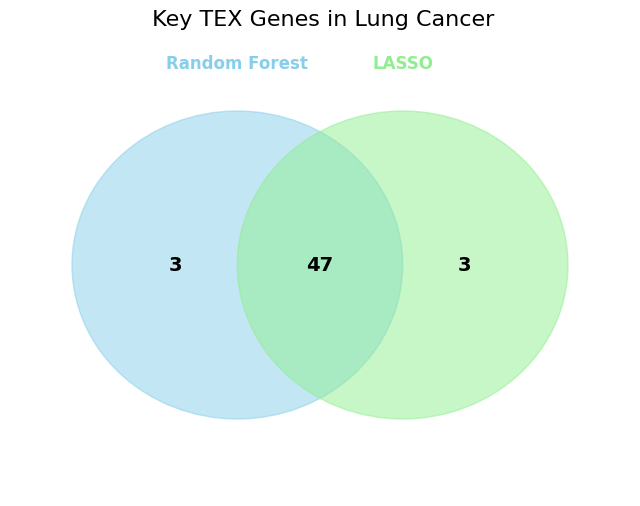

In [65]:
if 'genes_rf' in locals() and (len(genes_rf) > 0 or len(genes_lasso) > 0): # Only plot if there's data
    plt.figure(figsize=(8, 6))
    ax = plt.gca()

    # Draw Circles
    c1 = Circle((-0.4, 0), 0.8, color='skyblue', alpha=0.5)
    c2 = Circle((0.4, 0), 0.8, color='lightgreen', alpha=0.5)
    ax.add_patch(c1)
    ax.add_patch(c2)

    # Add Model Names above circles
    plt.text(-0.4, 1.0, 'Random Forest', ha='center', va='bottom', fontsize=12, fontweight='bold', color='skyblue')
    plt.text(0.4, 1.0, 'LASSO', ha='center', va='bottom', fontsize=12, fontweight='bold', color='lightgreen')

    # Add Text Counts inside circles
    plt.text(0.7, 0, f"{len(unique_lasso)}", ha='center', va='center', fontsize=14, fontweight='bold')
    plt.text(0, 0, f"{len(intersection)}", ha='center', va='center', fontsize=14, fontweight='bold')

    # Adjust position for RF unique count to avoid overlap with LASSO model name
    plt.text(-0.7, 0, f"{len(unique_rf)}", ha='center', va='center', fontsize=14, fontweight='bold')

    # Styling
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.2, 1.2)
    ax.axis('off')
    plt.title(" Key TEX Genes in Lung Cancer", fontsize=16) # Simplified title
    plt.savefig('venn_diagram_intersection.png', dpi=300)
    plt.show()
else:
    print("⚠️ Skipping Venn Diagram: No data for RF or LASSO top genes.")

# 7. Visualization: Volcano Plot (Custom)

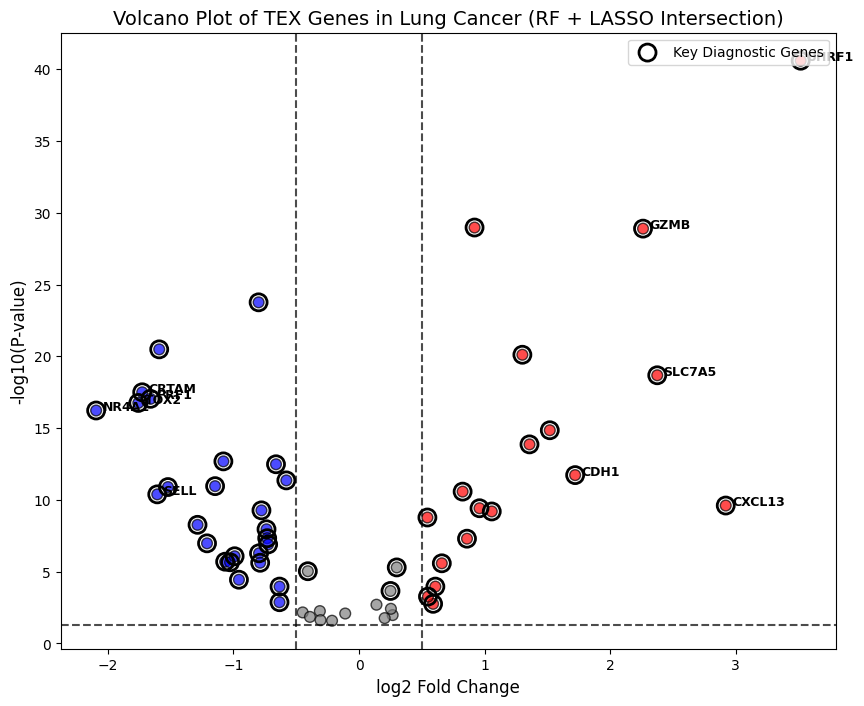

In [66]:
if not df_tex.empty: # Only plot if there are TEX genes
    # Ensure P.Value is converted to neg_log10 for plotting
    # Handle P.Value of 0 to avoid log(0) = inf
    min_p_val_for_plot = df_tex[df_tex['P.Value'] > 0]['P.Value'].min()
    df_tex['neg_log10_P.Value'] = -np.log10(df_tex['P.Value'].replace(0, min_p_val_for_plot / 10))

    plt.figure(figsize=(10, 8))

    # Define Thresholds
    lfc_thr = 0.5
    pv_thr = 0.05

    # Assign Colors
    colors = []
    for _, row in df_tex.iterrows():
        if row['logFC'] > lfc_thr and row['P.Value'] < pv_thr:
            colors.append('red') # Upregulated
        elif row['logFC'] < -lfc_thr and row['P.Value'] < pv_thr:
            colors.append('blue') # Downregulated
        else:
            colors.append('grey') # Not significant

    # Plot Scatter
    plt.scatter(df_tex['logFC'], df_tex['neg_log10_P.Value'], c=colors, s=60, alpha=0.7, edgecolor='k')

    # Highlight Key Genes (Intersection)
    key_subset = df_tex[df_tex['Gene_Clean'].isin(intersection)]
    if not key_subset.empty:
        plt.scatter(key_subset['logFC'], key_subset['neg_log10_P.Value'],
                    facecolors='none', edgecolors='black', s=150, linewidth=2, label='Key Diagnostic Genes')

        # Add Labels (Top 10 Key Genes)
        for i, row in key_subset.head(10).iterrows():
            plt.text(row['logFC']+0.05, row['neg_log10_P.Value'], row['Gene'], fontsize=9, fontweight='bold')
    else:
        print("⚠️ No key diagnostic genes to highlight in Volcano Plot.")

    # Add Threshold Lines
    plt.axvline(lfc_thr, color='black', linestyle='--', alpha=0.7)
    plt.axvline(-lfc_thr, color='black', linestyle='--', alpha=0.7)
    plt.axhline(-np.log10(pv_thr), color='black', linestyle='--', alpha=0.7)

    # Labels & Legend
    plt.xlabel('log2 Fold Change', fontsize=12)
    plt.ylabel('-log10(P-value)', fontsize=12)
    plt.title('Volcano Plot of TEX Genes in Lung Cancer (RF + LASSO Intersection)', fontsize=14)
    plt.legend(loc='upper right')
    plt.savefig('volcano_plot_tex_key_genes.png', dpi=300)
    plt.show()
else:
    print("⚠️ Skipping Volcano Plot: No TEX genes data to plot.")